# EDA: Telco Customer Churn

Este notebook realiza el Exploratory Data Analysis del dataset `telco.csv` según el Hackathon 3.
Pasos:

- Exploración del dataset
- Análisis de distribución de variables
- Detección de desbalance
- Identificación de problemas en los datos


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Carga de datos
df = pd.read_csv("telco.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Información general
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Identificación de problemas en los datos
# TotalCharges debería ser numérico, pero a veces viene como texto vacío ' '
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [5]:
# Rellenar nulos (clientes con tenure = 0)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

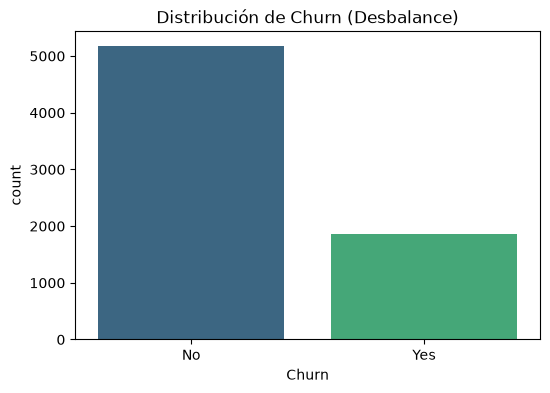

Proporción de la clase objetivo:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [6]:
# Detección de desbalance en la variable objetivo (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, palette="viridis")
plt.title("Distribución de Churn (Desbalance)")
plt.show()

print("Proporción de la clase objetivo:")
print(df["Churn"].value_counts(normalize=True) * 100)

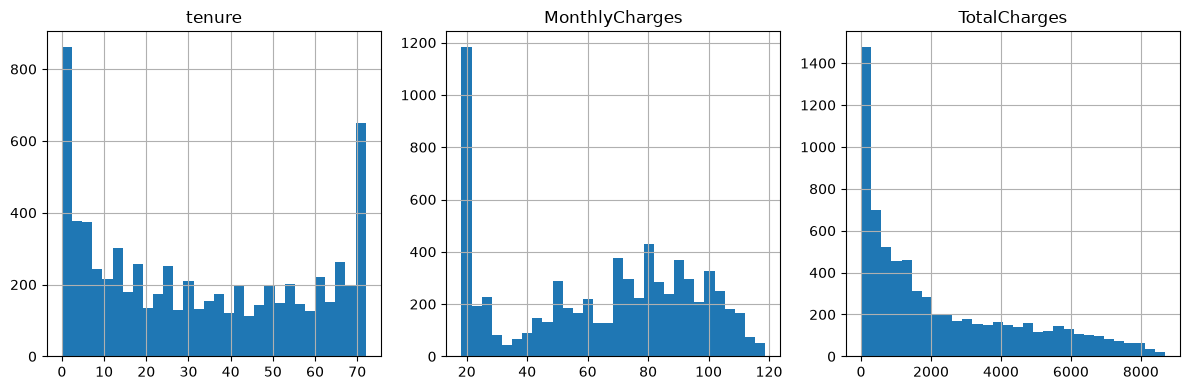

In [7]:
# Análisis de distribución de variables numéricas
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].hist(bins=30, figsize=(12, 4), layout=(1, 3))
plt.tight_layout()
plt.show()

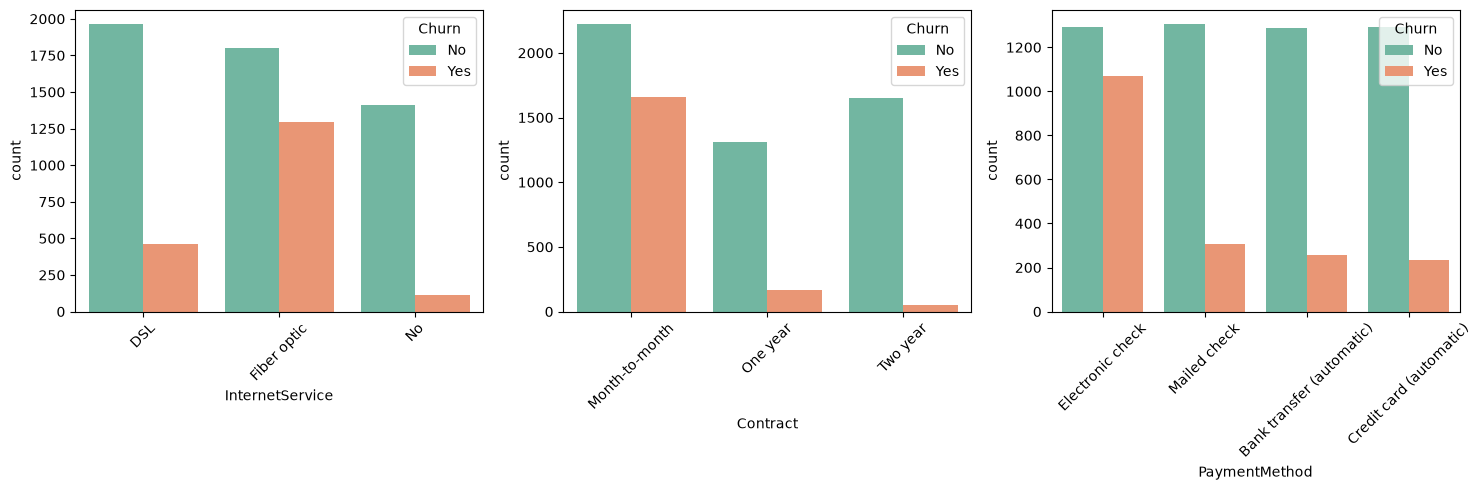

In [8]:
# Análisis de algunas variables categóricas clave vs Churn
cat_cols = ["InternetService", "Contract", "PaymentMethod"]
plt.figure(figsize=(15, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=col, hue="Churn", data=df, palette="Set2")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()